# Lab 2: Data Exploration and Inferences

## Task 6: Is India's air getting better or worse over time?


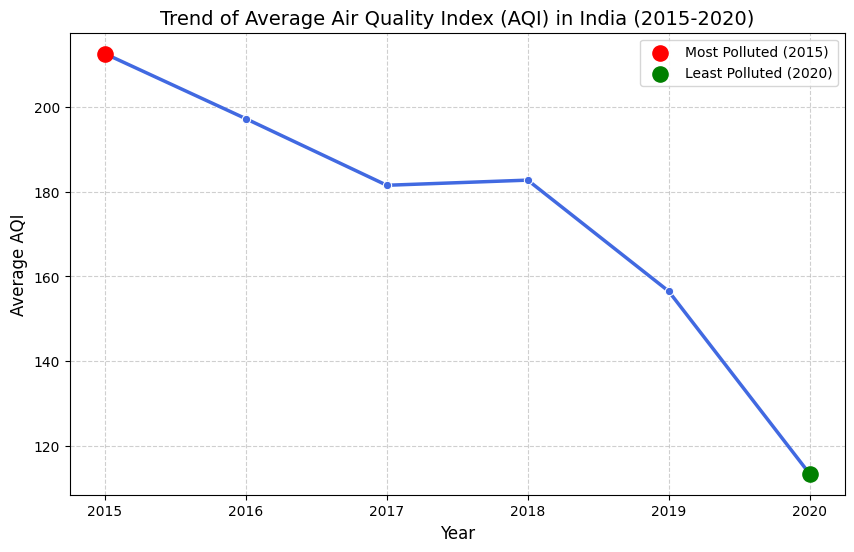

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the daily city AQI data
city_df = pd.read_csv('city_day.csv')

# Extract the temporal dimension (Year)
city_df['Date'] = pd.to_datetime(city_df['Date'])
city_df['Year'] = city_df['Date'].dt.year

# Group by Year to see the trend of average AQI
yearly_aqi = city_df.groupby('Year')['AQI'].mean().reset_index()


plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o', color='royalblue', linewidth=2.5)

# Highlight most and least polluted years
max_row = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
min_row = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

plt.scatter(max_row['Year'], max_row['AQI'], color='red', s=120, zorder=5, label=f"Most Polluted ({int(max_row['Year'])})")
plt.scatter(min_row['Year'], min_row['AQI'], color='green', s=120, zorder=5, label=f"Least Polluted ({int(min_row['Year'])})")

plt.title("Trend of Average Air Quality Index (AQI) in India (2015-2020)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average AQI", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**Response to the Journalist:**
The data shows that India's AQI has decreased in the period of 2015-2020. The year 2015 was the most polluted with the highest AQI and 2020 had the lowest AQI in the period. The possible reason for the low AQI in 2020 may have been because of the covid 19 pandemic, which caused a drop in vehicle usage and therefore emissions. 

## Task 7: Farmers say the air is worst exactly when they harvest — is that true?

C:\Users\KARUN NAGARAJ\AppData\Local\Temp\ipykernel_16904\1643057680.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_aqi, x='Month_Name', y='AQI', palette='magma_r')


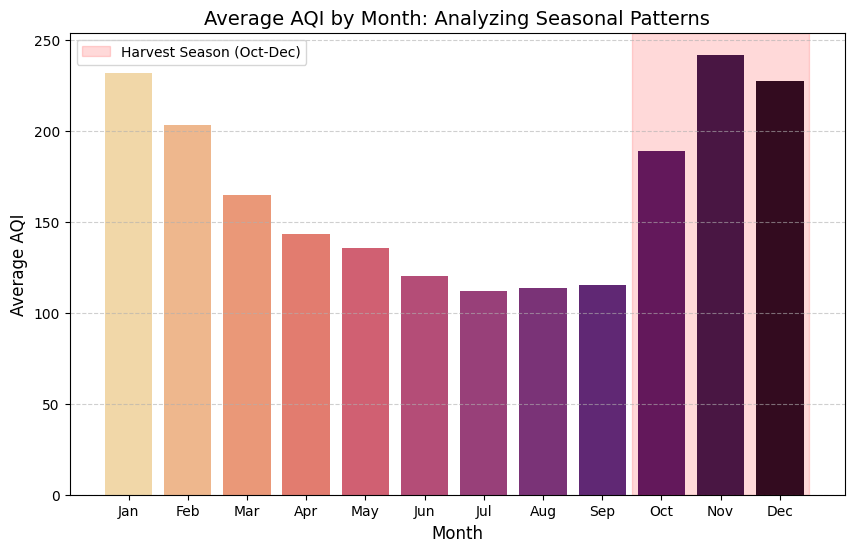

In [2]:
# Extract the month to test seasonality
city_df['Month'] = city_df['Date'].dt.month

# Map month numbers to readable names
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

# Group by month across all years
monthly_aqi = city_df.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi['Month_Name'] = monthly_aqi['Month'].map(month_map)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_aqi, x='Month_Name', y='AQI', palette='magma_r')

# Highlight the harvest season (October - December)
plt.axvspan(8.5, 11.5, color='red', alpha=0.15, label='Harvest Season (Oct-Dec)')

plt.title("Average AQI by Month: Analyzing Seasonal Patterns", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average AQI", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**Response to the Agricultural NGO:**

The data confirms the Agricultural NGO's claim that the air quality index is worse in the months of October to December which coincides with the harvest season. This proves that the widespread crop burning increases the amount of pollution. 

## Task 8: Can the two datasets talk to each other?

**Transformation Strategy & Merge Reasoning:**
Before we can merge `city_day.csv` and `crop_production.csv`, we must resolve massive inconsistencies in spatial and temporal areas. 
1. **Spatial Mismatch**: The AQI data is recorded at the *City* level, while the crop data is recorded at the *State* level. We must map every city to its parent state.
2. **Temporal Mismatch (The Anomaly)**: Although the task brief mentions the data spans 2015–2023, but the `city_day.csv` runs from 2015–2020, while `crop_production.csv` ends in 2015. If we try to merge on `(State, Year)`, we only get data for 2015—and unfortunately, the states recorded in both datasets for 2015 do not overlap. 

**T:** Because time spans are disconnected, we must completely drop the `Year` dimension. We will transform both datasets into historical cross-sectional summaries by grouping them exclusively by `State`. We will calculate the historical average pollution per state and historical total crop yield per state, and then merge them on `State`.

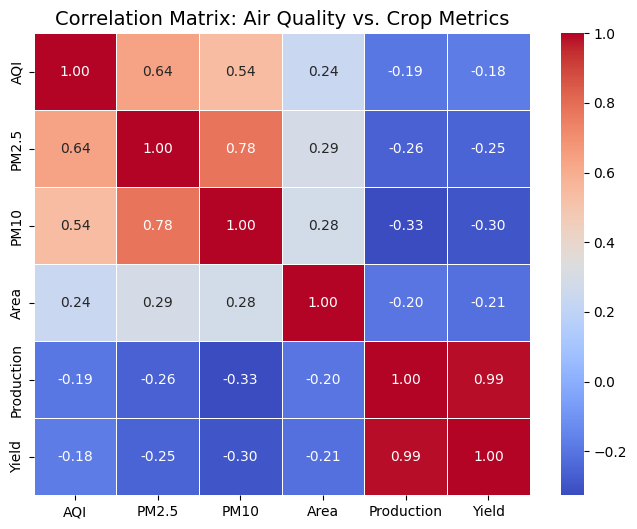

In [3]:
# Load the crop dataset
crop_df = pd.read_csv('crop_production.csv')

# 1. Map Cities to States
state_mapping = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}
city_df['State_Name'] = city_df['City'].map(state_mapping)

# Clean State Names in the crop dataset (remove trailing spaces like 'Telangana ')
crop_df['State_Name'] = crop_df['State_Name'].str.strip()

# 2. Aggregate City AQI data to State Level (Historical Means)
state_aqi = city_df.groupby('State_Name')[['AQI', 'PM2.5', 'PM10']].mean().reset_index()

# 3. Aggregate Crop data to State Level (Historical Sums)
state_crop = crop_df.groupby('State_Name')[['Area', 'Production']].sum().reset_index()

# Create a normalized 'Yield' metric (Production per Area unit)
state_crop['Yield'] = state_crop['Production'] / state_crop['Area']

# 4. Merge datasets on State_Name
merged_data = pd.merge(state_aqi, state_crop, on='State_Name', how='inner')

# 5. Explore relationships using a Correlation Matrix
plt.figure(figsize=(8, 6))
corr_matrix = merged_data[['AQI', 'PM2.5', 'PM10', 'Area', 'Production', 'Yield']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Air Quality vs. Crop Metrics", fontsize=14)
plt.show()

**Understanding the Correlation Matrix:**
A correlation matrix reveals the strength and direction of linear relationships between variables (ranging from -1 to 1). However, it only shows correlation, not causation; it cannot tell you if a change in one variable directly triggered a change in the other, as hidden external factors might influence both.

**Relationships Found:**
1. **High Positive Correlation between PM2.5 and PM10:**  Both metrics measure suspended particulate matter and originate from the exact same sources like vehicular exhaust, industrial emissions, and agricultural burning. Where one is present, the other will naturally be high.
2. **Negative Correlation between AQI and Crop Yield:** The matrix shows a negative relationship between heavy pollution (AQI) and overall agricultural efficiency (Yield). Thicker smog and high levels of ground-level ozone block sunlight. This heavily inhibits photosynthesis, stunting crop growth and reducing the efficiency of the land.

## Task 9: The minister needs to act — what do you tell her?



Based on the data review, here are three critical findings regarding our state's air quality and agriculture:

1. **Winter Spikes:** Air pollution spikes dramatically between October and December. This timeline perfectly matches the harvest season, strongly suggesting that crop residue burning is making the winter air hazardous.
2. **Hidden Extremes:** While average air quality has slowly improved over the last few years, these yearly averages hide the extreme winter spikes that are causing immediate health emergencies on the ground.
3. **Stunted Farming:** States with the worst air pollution also tend to have lower overall crop productivity. Thick smog blocks sunlight, which harms plant health and lowers farm output.

**Recommendation:** The best way to reduce pollution would be to stop crop burning to clear fields before the harvest. There are popular targeted machine subsidy programs that can allow for clearing of crops without burning. 

**Limitation:** Since the pollution data and crop data do not perefectly overlap due to the abstarction of states and a mismatch in year data, this analysis looks at broad averages. We cannot mathematically prove that a specific month of bad smog directly caused a lower crop yield that same year without updated, matching records.